# Titanic Analysis

This workbook provides my analysis of the Kaggle Titanic ML project (https://www.kaggle.com/competitions/titanic/overview).

The aim of this project is to get familiar with the ML workflow.

## 1. Framing the problem

The challenge of this project is to build a predictive model that answers the following question:
- "what sorts of people were more likely to survive?"

To do this, we can utilize the passenger data (including, e.g., name, age, gender, socio-econimic class, ...) to train and then test an ML model.
This suggests that the ML model we will build is:
- supervised: we have a survival metric available,
- classification: we need to classify our passengers as survived (1) or did not survive (0) in the 'Survived' column.

**Note:** The test set does not contain survival rates, so we will instead be limited to evaluating the performance of our model on the training set only. Hence, we will avoid loading in the test set, since it is not useful to our analysis.

We begin by importing the relevant libraries for this analysis:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data
The dataset contained in the 'data' folder consists of 3 csv files:
- 'train.csv' - the dataset to be utilized in traininig the ML model,
- 'test.csv' - the dataset to be utilized in testing our trained ML model,
- 'gender_submission.csv' - a set of predictions that assumes all and only female passengers survive, given as an example of what a submission file should look like

First step is to load the relevant training and test data:

In [3]:
df = pd.read_csv("data/train.csv") # training data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Each row of the data consists of a single passenger. The columns are structures as:

|Variable|Definition|
|-|-|
|PassengerId|Unique ID|
|Survived|Survived (0=No, 1=Yes) |
|Pclass| Socio-economic status (1=upper, 2=middle, 3=lower)|
|Name| Passenger name |
|Sex| Passenger sex (female/male)|
|Age| Passenger age (years, fractional if less than 1)|
|SibSp| # siblings / spouses aboard|
|Parch| # parents / children aboard|
|Ticket| Ticket number|
|Fare| Fare price|
|Cabin| Cabin number|
|Embarked| Port of embarkation (C=Cherbourg, Q=Queenstown, S=Southampton)|


## 3. Dataset Overview

In [4]:
print(f"rows={df.shape[0]}, columns={df.shape[1]}")
print()
print(df.info())

rows=891, columns=12

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [5]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Statistical summary of string-valued columns
df.describe(include="str")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


A brief look at the histograms associated with each input variable

## 4. Missing Data

In [13]:
# Create a new dataframe containing the sum of missing values, along with
# the percentage of missing values
missing_vals = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
# Remove all rows without missing values, then sort according to the
# missing value percentage
missing_vals = missing_vals[missing_vals["Missing Count"] > 0].sort_values("Missing %", ascending=False)
# Print the final result
missing_vals

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


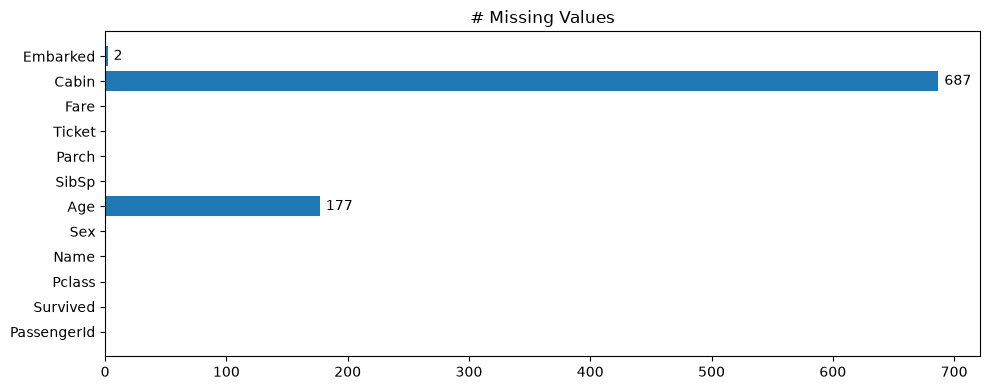

In [14]:
plt.subplots(figsize=(10, 4))
plt.barh(df.columns, df.isnull().sum())
for idx, val in enumerate(df.isnull().sum()):
    if val > 0:
        plt.text(val + 5, idx, str(val), va="center")
plt.title("# Missing Values")
plt.tight_layout()
plt.show()

From this, we can identify a few columns to drop, impute, or alter:
- **Name** - Not useful to analysis, drop column
- **Sex** - Alter to numerical values (0 or 1)
- **Age** - Proportion of data missing 177/891=0.199, impute on median
- **Ticket** - Note useful to analysis, drop column
- **Cabin** - Proportion of data missing 687/891=0.782, drop column
- **Embarked** - Proportion of data missing, impute on mode

## 5. Target Variable Analysis

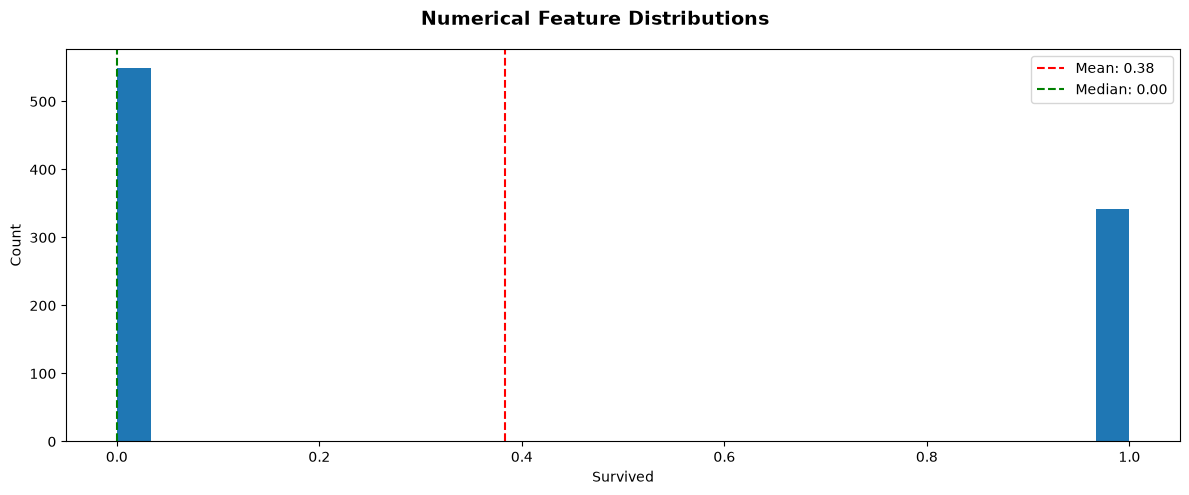

In [25]:
# Pick out the numerical columns
num_cols = ["Survived"] # Replace with chosen columns

fig, axes = plt.subplots(
    len(num_cols), 1,
    figsize=(12, 5 * len(num_cols)),
    squeeze=False
)

axes = axes.flatten()
for idx, col in enumerate(num_cols):
    axes[idx].hist(df[col].dropna(), bins=30)
    axes[idx].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[idx].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    axes[idx].legend()

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [33]:
survival_rate = df["Survived"].sum()/df["Survived"].count()
print(f"Survival Percentage = {round(100*survival_rate,2)}%")

Survival Percentage = 38.38%


We see an obvious imbalance in survival rates, which makes a lot of sense for the dataset being investigated here.

## 6. Univariate Analysis

In [34]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


### Numerical Features
Note that Pclass is a categorical feature, despite having numerical labels, since the numbers encode upper (1), middle (2), and lower (3) classes.

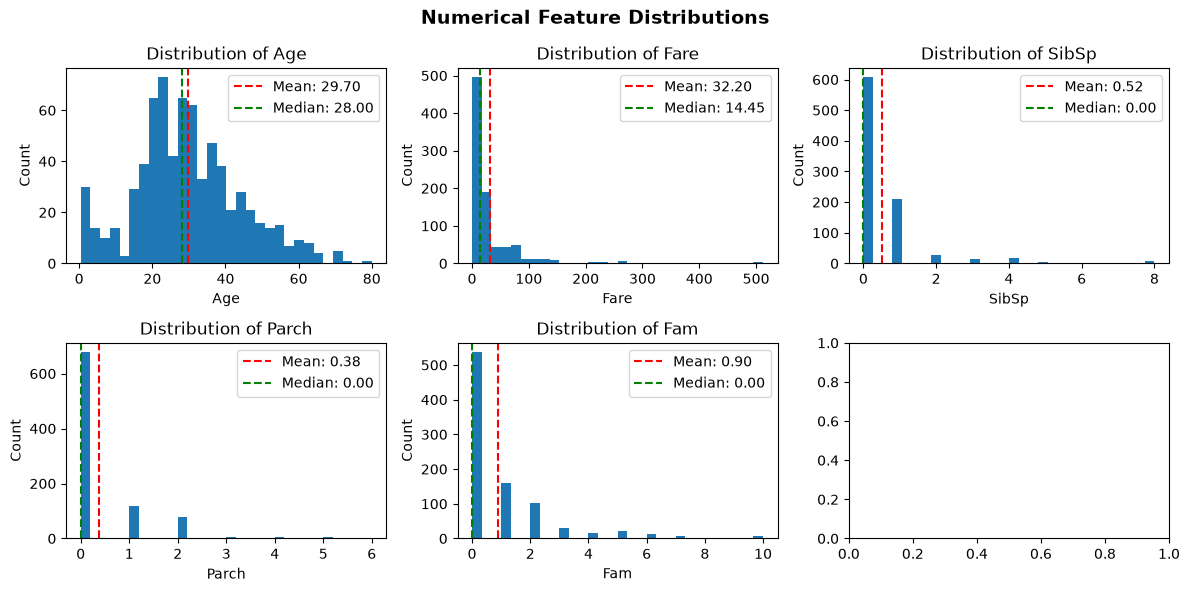

In [82]:
num_cols = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 1.5 * len(num_cols)),
    squeeze=False
)

axes = axes.flatten()
for idx, col in enumerate(num_cols):
    axes[idx].hist(df[col].dropna(), bins=30)
    axes[idx].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[idx].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    axes[idx].legend()
    axes[idx].set_title(f"Distribution of {col}")

# Add total family = SibSp + Parch
idx = 4
fam_data = df["Parch"] + df["SibSp"]
axes[idx].hist(fam_data.dropna(), bins=30)
axes[idx].axvline(fam_data.mean(), color="red", linestyle="--", label=f"Mean: {fam_data.mean():.2f}")
axes[idx].axvline(fam_data.median(), color="green", linestyle="--", label=f"Median: {fam_data.median():.2f}")
axes[idx].set_xlabel("Fam")
axes[idx].set_ylabel("Count")
axes[idx].legend()
axes[idx].set_title(f"Distribution of Fam")

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

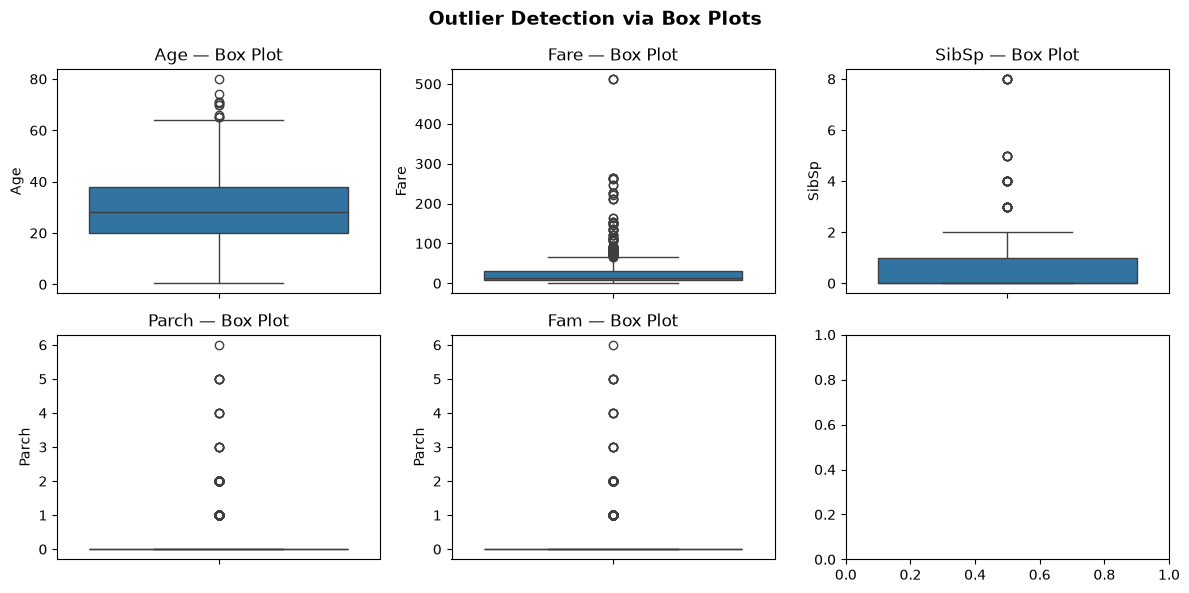

In [84]:
num_cols = [ "Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 1.5 * len(num_cols)),
    squeeze=False
)

axes = axes.flatten()

for idx, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[idx])
    axes[idx].set_title(f"{col} — Box Plot")
    
idx = 4
fam_data = df["Parch"] + df["SibSp"]
sns.boxplot(y=df[col], ax=axes[idx])
axes[idx].set_title(f"Fam — Box Plot")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**
- **Age** is relatively evenly distributed around it's mean of ~30
- **Family size**, including **Parch** and **SibSp** are all heavily right skewed, most passengers travelled alone
- **Fare** is heavily right skewed, with at least one outlier at very high prices

### Categorical Features

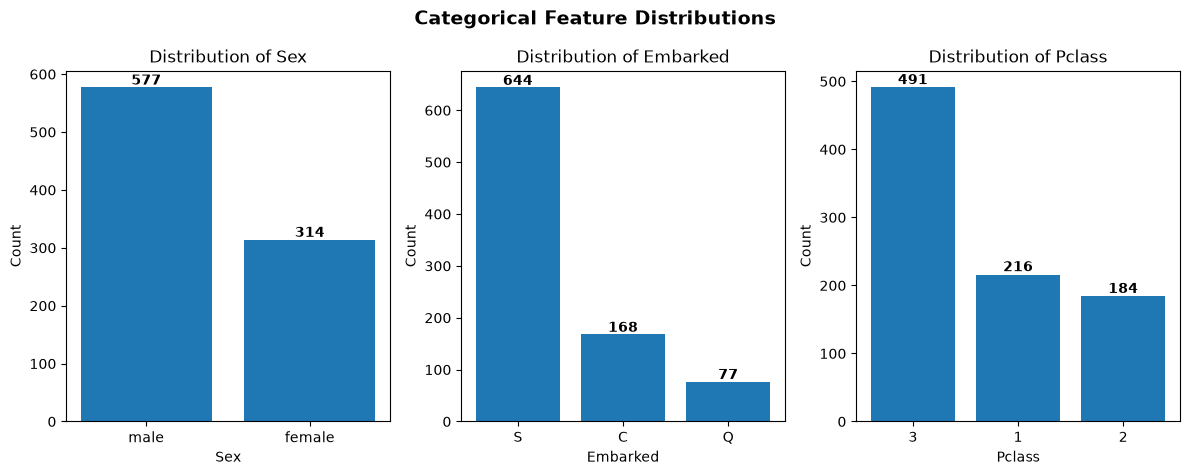

In [87]:
# Pick out the categorical columns
cat_cols = ["Sex", "Embarked", "Pclass"]

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 1.2 * len(num_cols)),
    squeeze=False
)
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[idx].bar(counts.index.astype(str), counts.values)
    axes[idx].set_title(f"Distribution of {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    for j, v in enumerate(counts.values):
        axes[idx].text(j, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**
- **Sex** is skewed towards nearly twice as many males as females
- **Embarked** is also heavily skewed towards 'S', with more than twice as many in this category than the other two categories combined
- **Pclass** is also heavily skewed towards lower class passengers

## 7. Bivariate Analysis

### Numerical Feature (Age)


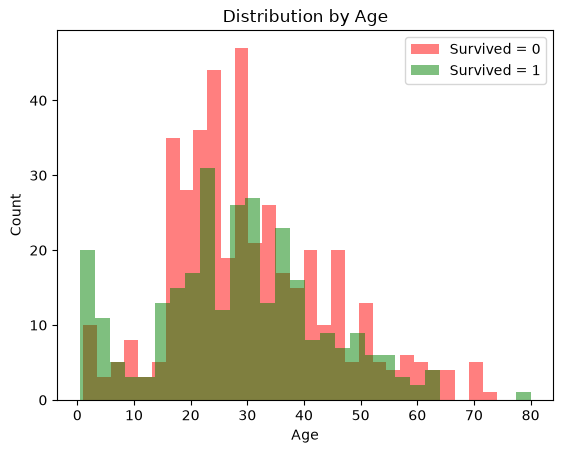

In [115]:
target_var = "Survived"
num_col = "Age"

plt.hist(df[df[target_var] == 0][num_col].dropna(), bins=30, color="red", alpha=0.5, label=f"{target_var} = 0")
plt.hist(df[df[target_var] == 1][num_col].dropna(), bins=30, color="green", alpha=0.5, label=f"{target_var} = 1")
plt.title(f"Distribution by {num_col}")
plt.xlabel(f"{num_col}")
plt.ylabel("Count")
plt.legend()
plt.show()


**Observations:**
- We see a higher rate of survial for the youngest passengers, which makes sense.
- Ages 15-30 see the lowest survival rate

It would be interesting to also break this down into Male vs Female survivorship based on age:

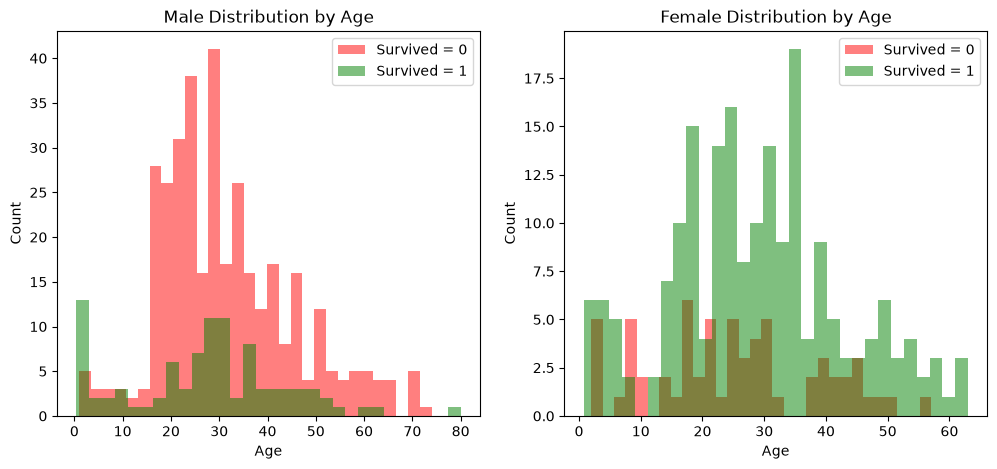

In [114]:
df_male = df[df["Sex"]=="male"]
df_female = df[df["Sex"]=="female"]


target_var = "Survived"
num_col = "Age"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_male[df_male[target_var] == 0][num_col].dropna(), bins=30, color="red", alpha=0.5, label=f"{target_var} = 0")
axes[0].hist(df_male[df_male[target_var] == 1][num_col].dropna(), bins=30, color="green", alpha=0.5, label=f"{target_var} = 1")
axes[0].set_title("Male Distribution by Age")
axes[0].set_xlabel(f"{num_col}")
axes[0].set_ylabel("Count")
axes[0].legend()


axes[1].hist(df_female[df_female[target_var] == 0][num_col].dropna(), bins=30, color="red", alpha=0.5, label=f"{target_var} = 0")
axes[1].hist(df_female[df_female[target_var] == 1][num_col].dropna(), bins=30, color="green", alpha=0.5, label=f"{target_var} = 1")
axes[1].set_title("Female Distribution by Age")
axes[1].set_xlabel(f"{num_col}")
axes[1].set_ylabel("Count")
axes[1].legend()


plt.show()

**Observations:**
- Males between ages 15-65 have enormously reduced odds of survival. The only survivor spike in this graph are for babies of age 0
- Females contain significantly more survivors across all age ranges, with the only exception of females age 9, which is rather strange. Though we must note that the number of females is much lower than the number of males, so this could be statistical variance.

### Numerical Feature (Fare)

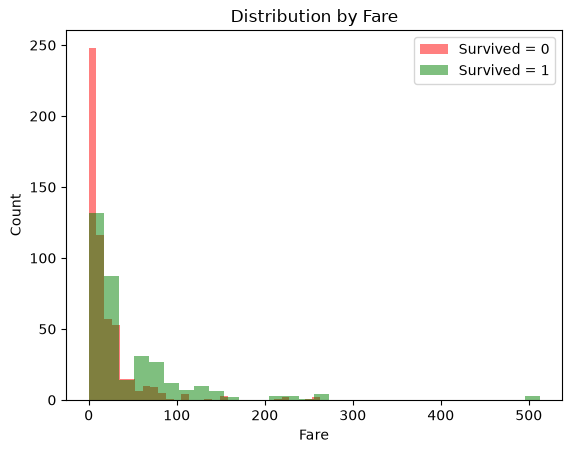

In [153]:
target_var = "Survived"
num_col = "Fare"

plt.hist(df[df[target_var] == 0][num_col].dropna(), bins=30, color="red", alpha=0.5, label=f"{target_var} = 0")
plt.hist(df[df[target_var] == 1][num_col].dropna(), bins=30, color="green", alpha=0.5, label=f"{target_var} = 1")
plt.title(f"Distribution by {num_col}")
plt.xlabel(f"{num_col}")
plt.ylabel("Count")
plt.legend()
plt.show()


In [160]:
print(f"Minimum fare: ${df["Fare"].min()}")
print(f"#Passengers with zero Fare: {df[df["Fare"]==0]["Fare"].count()}")

Minimum fare: $0.0
#Passengers with zero Fare: 15


**Observations:**
- Passengers with a very low fare (near zero) have a very low survival rate
- As fare increases, we see the Surivival rate also increase

### Numerical Features (SibSp and Parch)

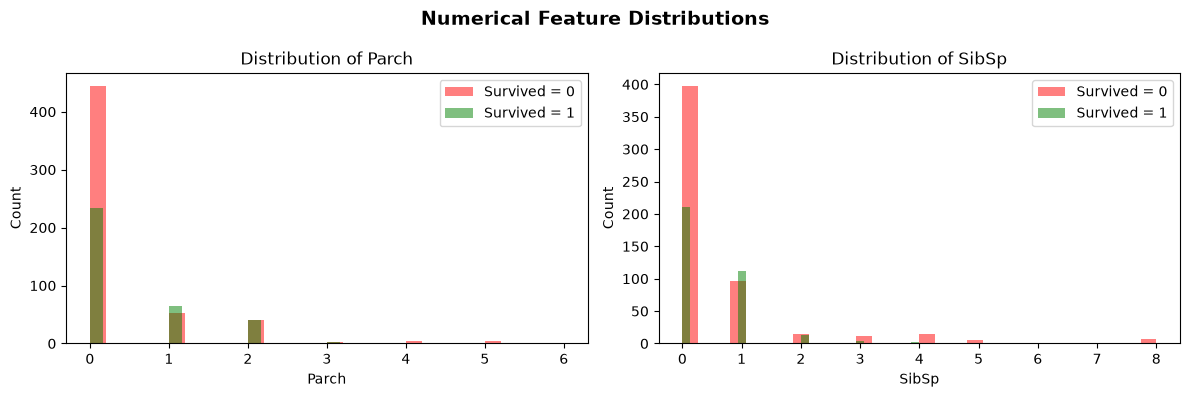

In [174]:
num_cols = ["Parch", "SibSp"]

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 2 * len(num_cols)),
    squeeze=False
)

axes = axes.flatten()

for idx, col in enumerate(num_cols):
    axes[idx].hist(df[df[target_var] == 0][col].dropna(), bins=30, color="red", alpha=0.5, label=f"{target_var} = 0")
    axes[idx].hist(df[df[target_var] == 1][col].dropna(), bins=30, color="green", alpha=0.5, label=f"{target_var} = 1")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    axes[idx].legend()
    axes[idx].set_title(f"Distribution of {col}")

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



### Discrete Numerical Features

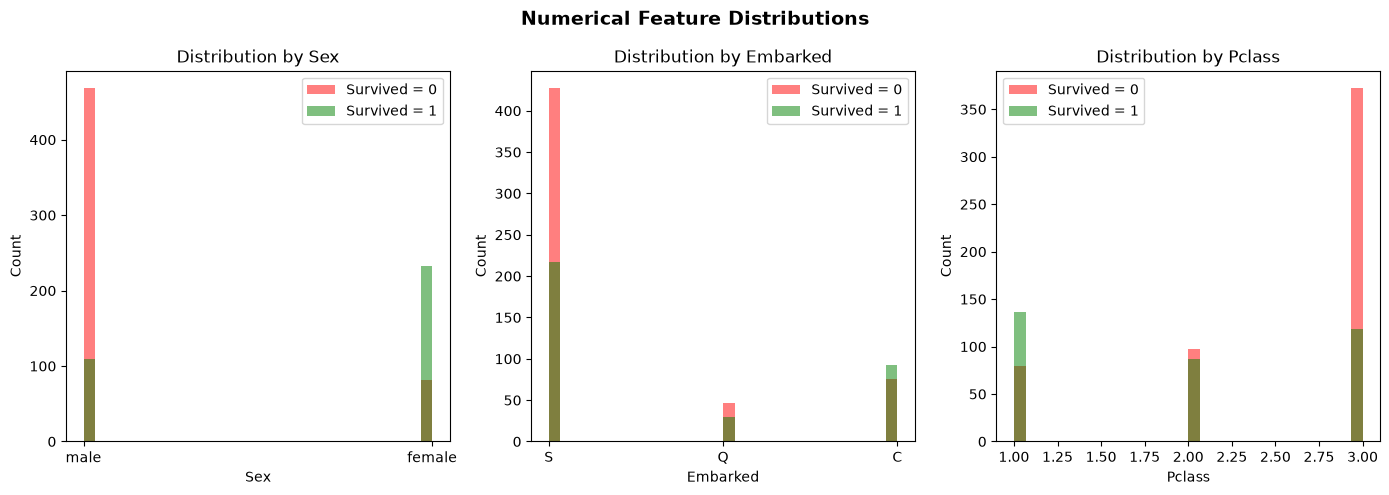

In [125]:
target_var = "Survived"
# Pick out the categorical columns
num_cols = ["Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5)) # Note n x m must equal the number of columns

for idx, col in enumerate(cat_cols):
    axes[idx].hist(df[df[target_var] == 0][col].dropna(), bins=30, color="red", alpha=0.5, label=f"{target_var} = 0")
    axes[idx].hist(df[df[target_var] == 1][col].dropna(), bins=30, color="green", alpha=0.5, label=f"{target_var} = 1")
    axes[idx].set_title(f"Distribution by {col}")
    axes[idx].set_xlabel(f"{col}")
    axes[idx].set_ylabel("Count")
    axes[idx].legend()

    
plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Observations:**
- **Sex** had a significant role in determining survival
- **Pclass** also played a significant role in survival, with upper class passengers being significantly more likely to survive, while lower class passengers were much more likely to not survive. Middle class was approximately an even split. 

In [140]:
female_survival = df_female["Survived"].mean()
male_survival = df_male["Survived"].mean()

print(f"Male survival percentage = {round(100*male_survival,2)}%")
print(f"Female survival percentage = {round(100*female_survival,2)}%")
print()

upper_survival = df[df["Pclass"]==1]["Survived"].mean()
lower_survival = df[df["Pclass"]==3]["Survived"].mean()
print(f"Upper class survival percentage = {round(100*upper_survival,2)}%")
print(f"Lower class survival percentage = {round(100*lower_survival,2)}%")

Male survival percentage = 18.89%
Female survival percentage = 74.2%

Upper class survival percentage = 62.96%
Lower class survival percentage = 24.24%


### Categorical Features


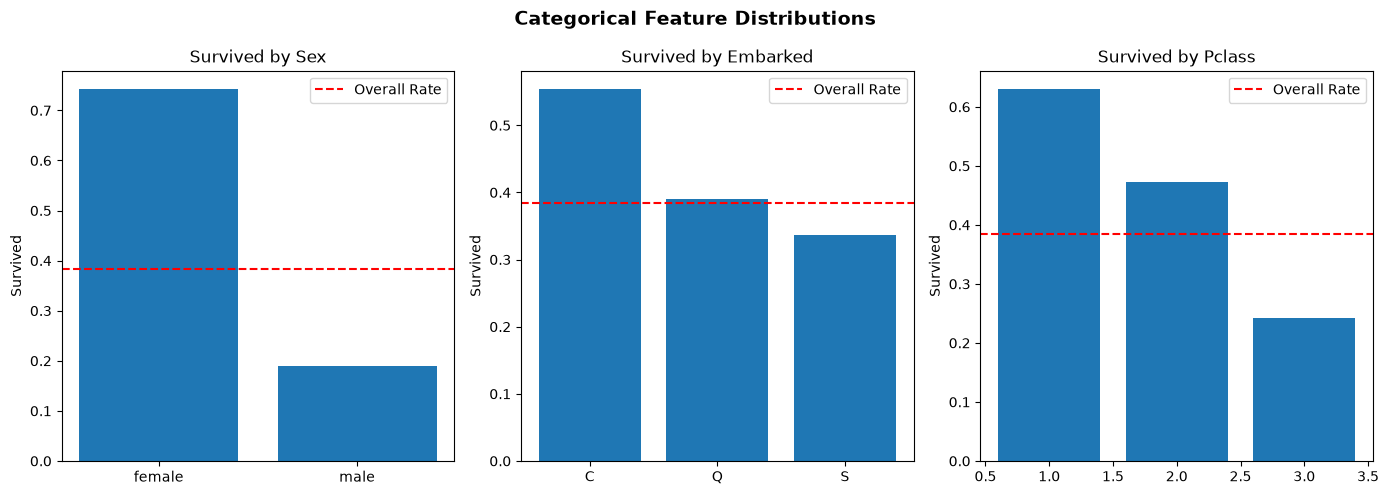

In [143]:
target_var = "Survived"
# Pick out the categorical columns
cat_cols = ["Sex", "Embarked", "Pclass"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5)) # Note n x m must equal the number of columns

for idx, col in enumerate(cat_cols):
    df_temp = df.groupby(col)[target_var].mean()
    axes[idx].bar(df_temp.index, df_temp.values)
    axes[idx].set_title(f"{target_var} by {col}")
    axes[idx].set_ylabel(target_var)
    axes[idx].axhline(y=df[target_var].mean(), color="red", linestyle="--", label="Overall Rate")
    axes[idx].legend()
    
plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Correlations

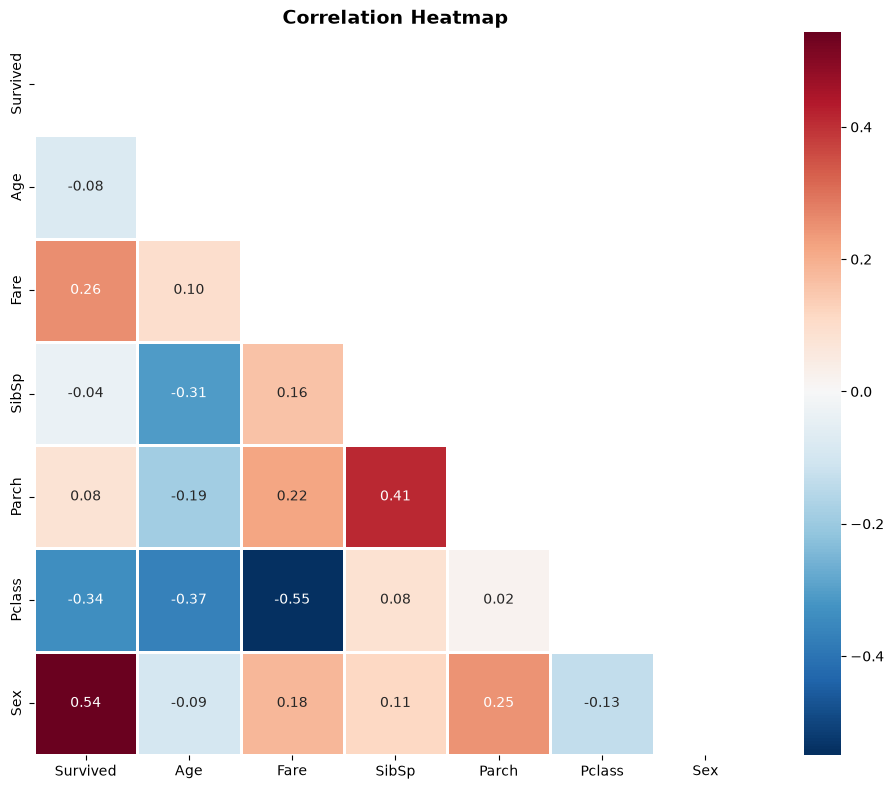

In [146]:
# First pick out our columns (these can be numeric or categorical)
num_cols = ["Survived", "Age","Fare", "SibSp", "Parch", "Pclass"]

numeric_df = df[num_cols].copy()
# Change binary columns to 0/1 numeric
numeric_df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

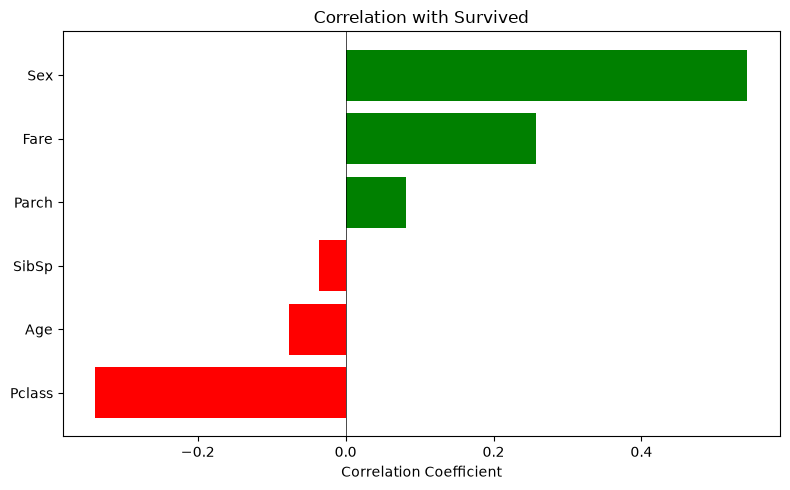

In [151]:
target_var = "Survived"

# First pick out our columns (these can be numeric or categorical)
numeric_df = df[num_cols].copy()

# Change binary columns to 0/1 numeric
numeric_df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

corr = numeric_df.corr()

# Correlation with target
target_corr = corr[target_var].drop(target_var).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["red" if v < 0 else "green" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {target_var}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

**Observations:**
- **Sex** is extremely correlated with survival, recall female=1 and male=0, meaning having Sex=female implies a much higher likelihood of survival
- **Fare** is fairly correlated with survival, which aligns with the survival per 

## 9. Summary of Findings

|Finding|Details|
|-|-|
|**Survival**| Only ~38% of the passengers survived|
|**Missing Data**| Cabin 77% missing, Age 20% missing, Embarked <1% missing|
|**Sex is the best predictor of survival**| 74% female survivors, 19% male|
|**Pclass and Fare also correlated with survival**| Correlation of ~0.3 for both|
|**Age**| Children had a significantly higher survival rate than Adults|
|**SibSp and Parch**| Larger family size increases survival chance|

